# FMC polygon drill notebook

In [84]:
import datetime
import geopandas as gpd
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt
from datetime import datetime
sns.set_theme(style="whitegrid")

import xarray as xr
import joblib
from matplotlib.colors import LinearSegmentedColormap
from dea_tools.classification import sklearn_flatten, sklearn_unflatten 
from dea_tools.plotting import display_map, rgb
from odc.algo import mask_cleanup
from datacube.utils.cog import write_cog
import datacube
import sys
from dea_tools.dask import create_local_dask_cluster
from dea_tools.spatial import xr_rasterize
from dea_tools.datahandling import load_ard
# Create local dask cluster to improve data load time
client = create_local_dask_cluster(return_client=True)

/env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39025 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/cate.kooymans@ga.gov.au/proxy/39025/status,
Dashboard: /user/cate.kooymans@ga.gov.au/proxy/39025/status,Workers: 1
Total threads: 31,Total memory: 237.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38723,Workers: 1
Dashboard: /user/cate.kooymans@ga.gov.au/proxy/39025/status,Total threads: 31
Started: Just now,Total memory: 237.21 GiB
Comm: tcp://127.0.0.1:35641,Total threads: 31
Dashboard: /user/cate.kooymans@ga.gov.au/proxy/45227/status,Memory: 237.21 GiB
Nanny: tcp://127.0.0.1:38591,


2025-02-18 03:19:07,357 - distributed.scheduler - WARNING - Detected different `run_spec` for key 'dataset-9dc5947070a7479a99b6baae091120ce' between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: (<function execute_task at 0x7f63282b3400>, (Dataset <id=9dc59470-70a7-479a-99b6-baae091120ce product=ga_s2bm_ard_3 location=s3://dea-public-data/baseline/ga_s2bm_ard_3/55/HGA/2018/05/25/20180525T012553/ga_s2bm_ard_3-2-1_55HGA_2018-05-25_final.odc-metadata.yaml>,), {})
new run_spec: (<function execute_task at 0x7f63282b3400>, (Dataset <id=9dc59470-70a7-479a-99b6-baae091120ce product=ga_s2bm_ard_3 location=s3://dea-public-data/baseline/ga_

In [85]:
dc = datacube.Datacube(app='fmc')

In [86]:
#define colour scale for plotting 
colours = [(0.87, 0, 0), (1, 1, 0.73), (0.165, 0.615, 0.957)]
cmap = LinearSegmentedColormap.from_list('fmc', colours, N=256)

In [87]:
def classify_FMC(data, model):
    """
    - data (xarray.Dataset): Sentinel-2 dataset containing required bands and optional multiple time steps. 
        
    - model (sklearn model): A pre-trained model for classification.
    
    Returns:
    - xarray.Dataset: A dataset containing the classified FMC results.
"""
    #calculate NDVI and NDII

    data['ndii']=((data.nbart_nir_1-data.nbart_swir_2)/(data.nbart_nir_1+data.nbart_swir_2))
    data['ndvi']=((data.nbart_nir_1-data.nbart_red)/(data.nbart_nir_1+data.nbart_red))

    # change order of variables to be the same as the model expects
    data_neworder = data[['ndvi','ndii', 'nbart_blue','nbart_green','nbart_red','nbart_red_edge_1' ,'nbart_red_edge_2' ,'nbart_red_edge_3','nbart_nir_1','nbart_nir_2','nbart_swir_2','nbart_swir_3']] 
    
    #flattern the data using SKlearn_flatten
    data_flat = sklearn_flatten(data_neworder)
    
    #classify the data using the model
    print("predicting...")
    out_class = model.predict(data_flat)
    
    #return_classification to original shape
    #transpose because coords sideways when moving from Numpy to Xarray
    returned_result = sklearn_unflatten(out_class, data).transpose()
    
    #make results a dataset
    dataset_result = xr.Dataset({'LFMC':returned_result}, coords=data.coords, attrs=data.attrs)
    
    #return
    return dataset_result

In [88]:
# import model
model = joblib.load('/home/jovyan/gdata1/projects/Hazards/Fuel_moisture/RF_AllBands_noLC_DEA_labeless.joblib')

In [89]:
# shapefile = '/home/jovyan/Supplementary_data/DEA_Wetlands_Insight_Tool/hird.shp'
# shapefile ='/home/jovyan/gdata1/projects/Hazards/burn mapping/kangaroo_Island_SA_2020_CY_ARDC_polygons.gpkg'
shapefile ='/home/jovyan/Hazards/burn_shapefiles/North_black_range_2019.shp'

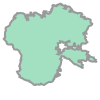

In [90]:
# This cell loads and plots the wetlands polygon. If no output, check your polygon
poly = gpd.read_file(shapefile)
poly.geometry[1]

In [91]:
# Specifying coordinate reference system of the polygon.
gpgon = datacube.utils.geometry.Geometry(poly.geometry[1], crs=poly.crs)

In [92]:
# Select time period. Consistent data is available from 01-09-1987.
time = ("2015-06-01", "2020-06-01")


In [93]:

# df = dc.load(product=['ga_s2am_ard_3', 'ga_s2bm_ard_3'],
#             measurements= ['nbart_blue','nbart_green','nbart_red','oa_fmask', 'nbart_red_edge_1' ,'nbart_red_edge_2' ,'nbart_red_edge_3','nbart_nir_1','nbart_nir_2','nbart_swir_2','nbart_swir_3', 'oa_nbart_contiguity'],
#             geopolygon=gpgon,
#             resolution=(-20, 20),
#             time = time,
#             resampling={"*": "bilinear"},
#             output_crs= 'EPSG:3577')

In [94]:
# Load Landsat 5, 7 and 8 data. Not including Landsat 7 SLC off period (31-05-2003 to 06-04-2022).
bands =['nbart_blue','nbart_green','nbart_red','oa_fmask', 'nbart_red_edge_1' ,'nbart_red_edge_2' ,'nbart_red_edge_3','nbart_nir_1','nbart_nir_2',
        'nbart_swir_2','nbart_swir_3', 'oa_nbart_contiguity']

df = load_ard(
    dc,
    products=['ga_s2am_ard_3', 'ga_s2bm_ard_3'],
    ls7_slc_off=True,
    measurements=bands,
    geopolygon=gpgon,
    output_crs="EPSG:3577",
    resolution=(-20, 20),
    resampling={"*": "bilinear"},
    time=time,
    min_gooddata=0.80,
    group_by="solar_day",
    mask_pixel_quality=False,
    dask_chunks={"time":1, "x": 2048, "y": 2048},
)

# Load into memory using Dask
df.load()

Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
Counting good quality pixels for each time step using fmask


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Filtering to 129 out of 263 time steps with at least 80.0% good quality pixels
Returning 129 time steps as a dask array


<xarray.Dataset> Size: 4GB
Dimensions:              (time: 129, y: 1276, x: 1195)
Coordinates:
  * time                 (time) datetime64[ns] 1kB 2015-09-13T00:06:31.458000...
  * y                    (y) float64 10kB -3.967e+06 -3.967e+06 ... -3.993e+06
  * x                    (x) float64 10kB 1.582e+06 1.582e+06 ... 1.605e+06
    spatial_ref          int32 4B 3577
Data variables:
    nbart_blue           (time, y, x) int16 393MB 517 458 354 ... 277 308 311
    nbart_green          (time, y, x) int16 393MB 721 619 484 ... 576 657 646
    nbart_red            (time, y, x) int16 393MB 757 605 489 ... 516 617 623
    oa_fmask             (time, y, x) uint8 197MB 1 1 1 1 1 1 1 ... 1 1 1 1 1 1
    nbart_red_edge_1     (time, y, x) int16 393MB 1114 982 763 ... 1120 1153
    nbart_red_edge_2     (time, y, x) int16 393MB 2038 1736 1529 ... 2481 2556
    nbart_red_edge_3     (time, y, x) int16 393MB 2139 1858 1574 ... 2940 2976
    nbart_nir_1          (time, y, x) int16 393MB 2600 2014 1726 ... 3345 3289
    nbart_nir_2          (time, y, x) int16 393MB 2539 2180 1769 ... 3385 3410
    nbart_swir_2         (time, y, x) int16 393MB 2091 1871 1440 ... 2076 2081
    nbart_swir_3         (time, y, x) int16 393MB 1267 1075 803 ... 1113 1124
    oa_nbart_contiguity  (time, y, x) uint8 197MB 1 1 1 1 1 1 1 ... 1 1 1 1 1 1
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

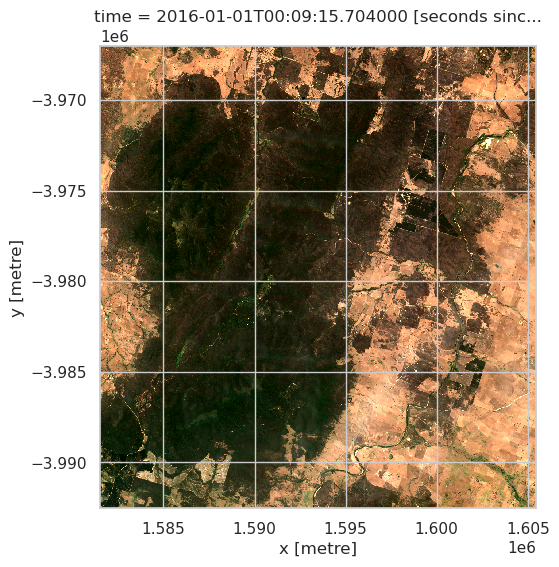

In [95]:
rgb(df.isel(time=1))

In [96]:
# Rasterise the shapefile where poly is the vector data and pv is the xarray template
poly_raster = xr_rasterize(poly, df.nbart_blue) > 0

In [97]:
df = df.where(poly_raster)

In [98]:
# Define masks. seperate cloud + shadow mask from water+ no_data mask becasue we want to do buffering of could+shadow but not water+no_data

cloud_mask = (df.oa_fmask == 2) | (df.oa_fmask == 3)
water_mask = (df.oa_fmask == 5) | (df.oa_fmask == 0) | (df.oa_nbart_contiguity == 0)


In [99]:
#perfrom 1 pixel opening on cloud + shadow. three pixle dilation 
better_cloud_mask = mask_cleanup(mask=cloud_mask, mask_filters=[("opening", 1),("dilation", 3)])

#drop fmask from dataset before we classify
df = df.drop(['oa_fmask', 'oa_nbart_contiguity'])

/tmp/ipykernel_133/696312390.py:5: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df = df.drop(['oa_fmask', 'oa_nbart_contiguity'])


In [100]:
df = df.where(df > -999, 0)

In [101]:
#perfrom calssification of data usinf model defined above
FMC_data = classify_FMC(df, model)

predicting...


In [102]:
#apply masks we generated before to classified data. it can be masked before we classify but then these pixels have a 0 value and it is better if it is 'no data'

masked_data = FMC_data.where(~better_cloud_mask)
masked_data = masked_data.where(~water_mask)
masked_data = masked_data.where(poly_raster) #make sure polyhon mask is applied

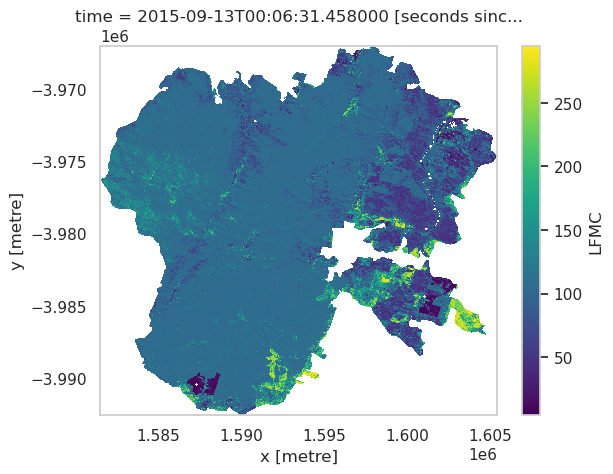

In [103]:
masked_data.LFMC.isel(time=0).plot()

In [104]:
for time in masked_data.time:
    print(time.data)

    time_slice = masked_data.sel(time=time)

2015-09-13T00:06:31.458000000
2016-01-01T00:09:15.704000000
2016-01-11T00:06:45.501000000
2016-02-10T00:06:25.461000000
2016-04-20T00:06:30.462000000
2016-05-20T00:05:06.808000000
2016-05-30T00:06:34.457000000
2016-06-29T00:06:03.142000000
2016-08-08T00:03:48.043000000
2016-08-18T00:06:31.455000000
2016-09-17T00:04:05.298000000
2016-09-27T00:06:24.461000000
2016-11-06T00:06:27.462000000
2016-11-16T00:02:16.461000000
2016-11-26T00:02:16.461000000
2017-01-15T00:02:42.541000000
2017-02-04T00:06:22.464000000
2017-03-06T00:06:21.457000000
2017-03-26T00:06:23.464000000
2017-05-25T00:06:31.455000000
2017-06-14T00:06:29.461000000
2017-06-24T00:02:16.457000000
2017-07-04T00:06:28.457000000
2017-07-14T00:02:18.464000000
2017-07-24T00:06:30.463000000
2017-08-08T00:06:27.463000000
2017-08-13T00:06:30.462000000
2017-08-23T00:02:19.458000000
2017-08-28T00:06:24.455000000
2017-09-02T00:06:28.460000000
2017-09-12T00:03:18.263000000
2017-09-17T00:06:18.455000000
2017-09-27T00:02:25.464000000
2017-10-02

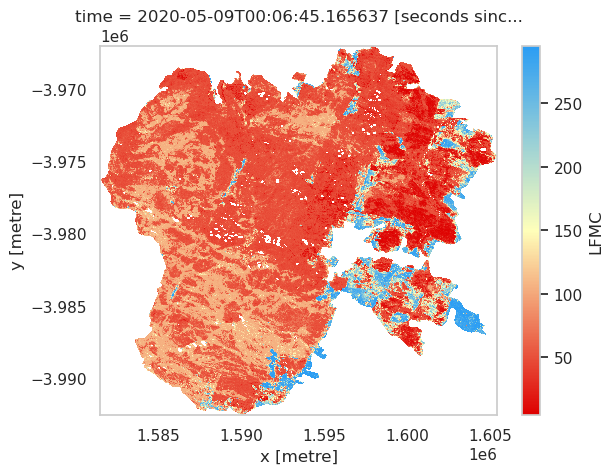

In [105]:
time_slice.LFMC.plot(cmap=cmap)

In [106]:


#, "xkcd_rgb: coral", "xkcd_rgb: pale yellow", "xkcd_rgb: powder blue", "xkcd_rgb: azure", "xkcd_rgb: cerulean blue", "xkcd_rgb: white"]


In [107]:
def count_classes(x:[], dataset):
    big_table = {}
    for time in dataset.time:
        date = time.data
        slice_of_data = dataset.sel(time=date)
        table = {}
        xn = 0
        cloud = ~np.isfinite(slice_of_data)
        table['cloud']=int(np.sum(cloud).data)
        table['date'] = datetime.strptime(str(date)[0:10], '%Y-%m-%d')
        for xi in x:
            count_ = (xn < slice_of_data) & (slice_of_data <= xi)
            count_ = int(np.sum(count_).data)
            xn = xi
            table[xi] = count_

        big_table[str(date)[0:10]] = table
    return big_table



In [108]:
test_table = count_classes([50, 100,150,200,250,300,350], masked_data.LFMC)

In [109]:
value_table = pd.DataFrame.from_dict(test_table, orient='index')

In [110]:
value_table

,cloud,date,50,100,150,200,250,300,350
2015-09-13,584354,2015-09-13,45033,219195,620056,33195,15513,7474,0
2016-01-01,641452,2016-01-01,138529,404822,337205,2395,319,98,0
2016-01-11,589691,2016-01-11,215019,381637,334626,3262,512,73,0
2016-02-10,583860,2016-02-10,126463,345414,425931,22302,15739,5111,0
2016-04-20,602281,2016-04-20,72251,248299,587578,10521,3409,481,0
...,...,...,...,...,...,...,...,...,...
2020-04-14,588427,2020-04-14,369046,357777,119294,19293,24119,46864,0
2020-04-19,606240,2020-04-19,367578,313713,142026,21412,25017,48834,0
2020-04-24,588869,2020-04-24,362055,339085,142850,23580,28107,40274,0
2020-05-04,593000,2020-05-04,297314,391452,157114,21940,26708,37292,0


In [111]:
# Calculate total possible pixels from mask
total_pixels = int(np.sum(poly_raster.data))
total_pixels

941648

In [112]:
non_data_pixels =  int(np.sum(~poly_raster.data))
non_data_pixels

583172

In [113]:
# value_table[100] = value_table[100] / value_table['total'] *100

In [114]:
for x in [50, 100,150,200,250,300,350]:
    value_table[x] = value_table[x] / total_pixels *100

value_table['cloud'] = (value_table['cloud']-non_data_pixels) / total_pixels *100

In [115]:
value_table

,cloud,date,50,100,150,200,250,300,350
2015-09-13,0.125525,2015-09-13,4.782360,23.277807,65.847960,3.525203,1.647431,0.793715,0.0
2016-01-01,6.189149,2016-01-01,14.711336,42.990799,35.810090,0.254341,0.033877,0.010407,0.0
2016-01-11,0.692297,2016-01-11,22.834329,40.528626,35.536209,0.346414,0.054373,0.007752,0.0
2016-02-10,0.073063,2016-02-10,13.429965,36.681860,45.232507,2.368401,1.671431,0.542772,0.0
2016-04-20,2.029315,2016-04-20,7.672825,26.368558,62.398901,1.117296,0.362025,0.051081,0.0
...,...,...,...,...,...,...,...,...,...
2020-04-14,0.558064,2020-04-14,39.191503,37.994771,12.668641,2.048855,2.561361,4.976807,0.0
2020-04-19,2.449748,2020-04-19,39.035606,33.315315,15.082706,2.273886,2.656725,5.186014,0.0
2020-04-24,0.605003,2020-04-24,38.449081,36.009740,15.170212,2.504120,2.984873,4.276970,0.0
2020-05-04,1.043702,2020-05-04,31.573794,41.570948,16.685003,2.329958,2.836304,3.960291,0.0


In [116]:
def rgb_code_fix(test_tupple):
    new_tupple = (test_tupple[0]/255,test_tupple[1]/255,test_tupple[2]/255)
    return new_tupple

In [117]:
# pal = ((245, 66, 66), #red
# (245, 135, 66), #coral
# (255, 251, 145), #yellow
# (141, 181, 150), #green
# (177, 226, 240), #blue
# (62, 145, 168), #darb lue
# (1, 1, 1))


pal = ((0.9608, 0.2588, 0.2588),
(0.9608, 0.5294, 0.2588),
(1.0, 0.9843, 0.5686),
((0.5529, 0.7098, 0.5882)),
(0.6941, 0.8863, 0.9412),
(0.2431, 0.5686, 0.6588),
(1, 1, 1))

In [118]:
import matplotlib.dates as mdates

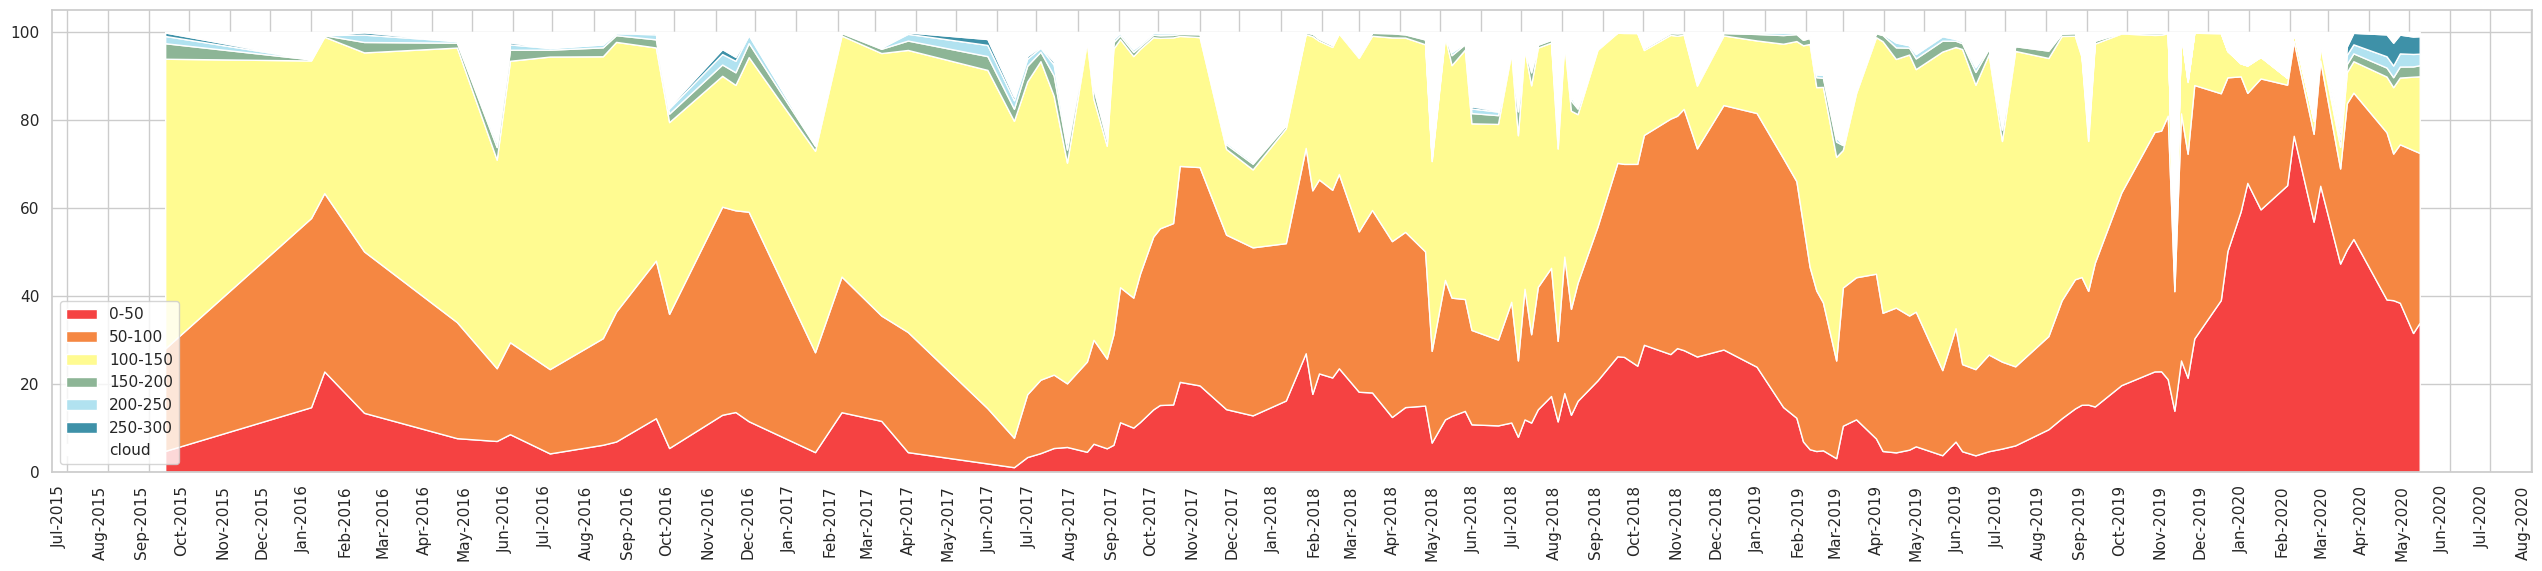

In [119]:

plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["text.usetex"] = False

width=32,
height=6,

fig = plt.pyplot.figure()
fig.set_size_inches(32, 6)
ax = fig.add_subplot(111)
ax.autoscale(enable=True)




ax.stackplot(value_table['date'],value_table[50], value_table[100],value_table[150],value_table[200],value_table[250],value_table[300], value_table['cloud'], 
             labels=['0-50','50-100','100-150','150-200','200-250','250-300','cloud'], colors = pal)
legend = ax.legend(loc="lower left")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
# Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax.get_xticklabels(which='major'):
    label.set(rotation=90, horizontalalignment='right')
# handles = legend.legend_handles

# for i, handle in enumerate(handles):
#         handle.set_facecolor(pal[i])
#         # handle.set_alpha(0.7)